# Regression Analysis on Synthetic Energy Data: Linear vs Ridge Models and Residual Diagnostics

This notebook builds a synthetic energy-consumption dataset and uses it to compare **ordinary least squares (OLS)** and **Ridge regression**. Because the data are simulated from a known linear model, we can go beyond pure prediction and also examine how well each method recovers the underlying coefficients.

The analysis is organised as follows:
1. generate the synthetic dataset,
2. explore feature-target relationships,
3. split and scale the data,
4. fit OLS and Ridge models,
5. compare train/test performance,
6. study coefficient shrinkage and Ridge paths,
7. run residual diagnostics,
8. test sensitivity to higher noise,
9. summarise the modelling conclusions.

## 1. Setup and imports

We import the core numerical, visualisation, and machine-learning libraries used throughout the notebook. In addition to the basic regression tools, we also load **RidgeCV** for cross-validated regularisation strength selection and **SciPy** for Q-Q plot diagnostics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(0)

## 2. Create the synthetic energy dataset

We simulate four explanatory variables:
- **temperature**,
- **humidity**,
- **wind speed**,
- **weekend indicator**.

The target variable, **consumption**, is then generated from a linear model
$$
Y = X\beta + \varepsilon,
$$
where `true_beta` contains the data-generating coefficients and `noise` represents random variation not explained by the predictors. This is useful because it gives us a known ground truth against which estimated coefficients can later be compared.

In [2]:
n = 1000

df = pd.DataFrame({
    'temperature': 15 + 10 * np.random.randn(n),
    'humidity': 50 + 20 * np.random.randn(n),
    'wind_speed': 5 + 2 * np.random.randn(n),
    'is_weekend': np.random.randint(0, 2, size=n)
})

true_beta = np.array([-3.0, 0.5, -1.0, 10.0])
noise = 5 * np.random.randn(n)

df['consumption'] = (
    df[['temperature', 'humidity', 'wind_speed', 'is_weekend']].values @ true_beta
    + noise
)

## 3. Define features and target

We separate the predictors from the response variable. Keeping the feature names in a dedicated list is convenient for repeated plotting, tabulation, and interpretation later in the notebook.

In [3]:
feature_cols = ['temperature', 'humidity', 'wind_speed', 'is_weekend']
X = df[feature_cols]
y = df['consumption']

## 4. Inspect the dataset

A quick preview confirms the structure of the synthetic dataset and helps verify that all variables have been created as intended.

In [4]:
df.head()

,temperature,humidity,wind_speed,is_weekend,consumption
0,32.640523,61.119254,1.934158,1,-54.568408
1,19.001572,67.849478,1.576060,1,-15.662960
2,24.787380,41.553704,5.092270,1,-41.124934
3,37.408932,52.094281,3.083251,1,-82.120299
4,33.675580,54.561067,4.838377,0,-75.256637


## 5. Summary statistics

Before fitting any models, it is useful to inspect basic descriptive statistics. This gives a sense of the scale and spread of the variables and can reveal whether some features are measured on very different scales.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,1000.0,14.547433,9.875270,-15.461431,8.015799,14.419720,21.069506,42.593551
humidity,1000.0,50.272339,19.372889,-9.892257,36.923004,50.521240,62.509601,113.419495
wind_speed,1000.0,4.897543,1.909189,-1.233713,3.526671,4.895004,6.243232,10.858192
is_weekend,1000.0,0.536000,0.498952,0.000000,0.000000,1.000000,1.000000,1.000000
consumption,1000.0,-18.022956,32.256951,-113.238169,-40.595933,-17.995388,4.087605,87.264486


## 6. Scatter plots of each feature against consumption

These plots provide a first visual check of whether linear modelling is plausible. Roughly increasing or decreasing linear trends support the use of OLS/Ridge, whereas strong curvature or changing variance patterns would suggest that richer models may be needed.

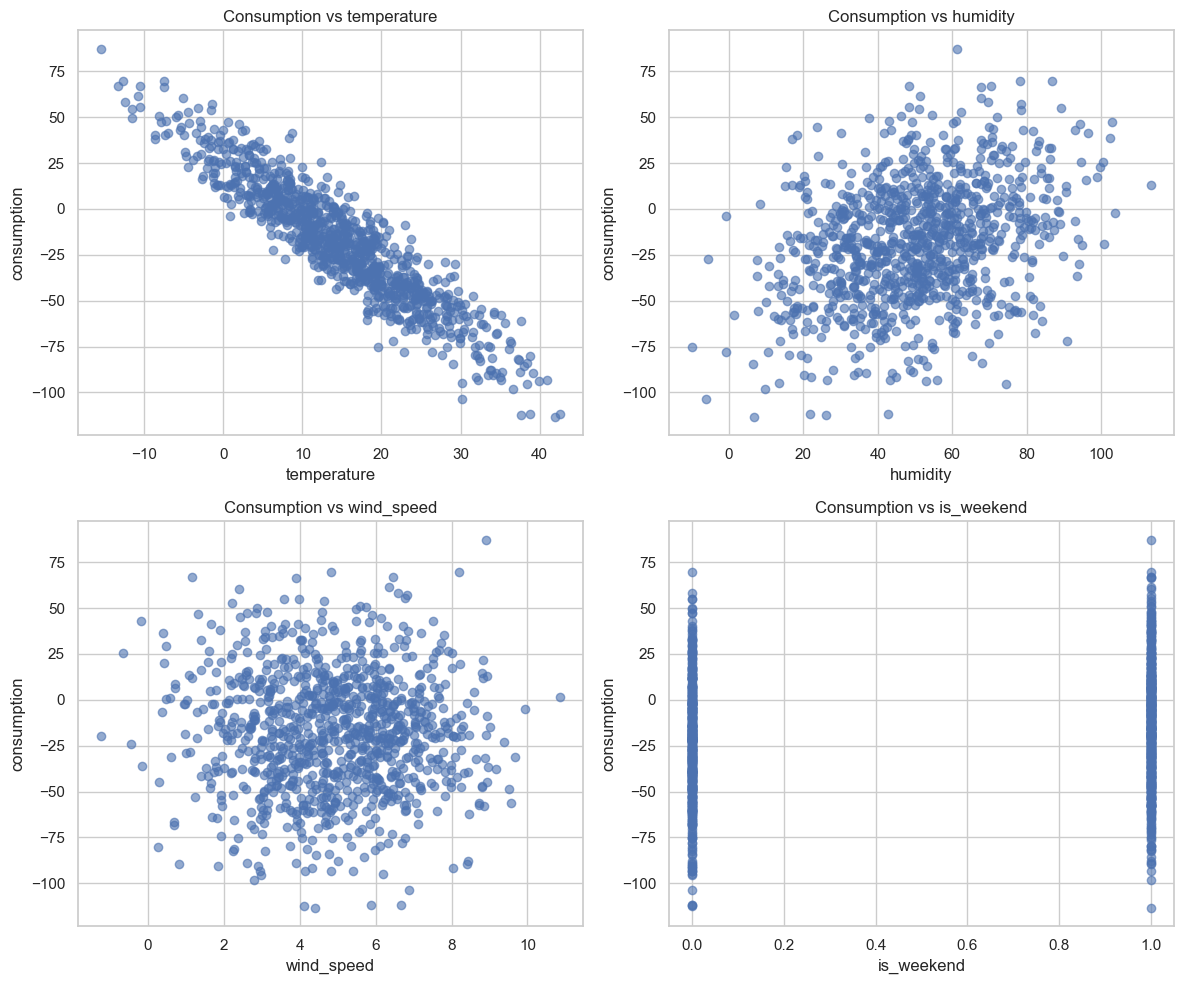

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), feature_cols):
    ax.scatter(df[col], y, alpha=0.6)
    ax.set_xlabel(col)
    ax.set_ylabel('consumption')
    ax.set_title(f'Consumption vs {col}')

plt.tight_layout()
plt.show()

## 7. Scatter plots with correlation values

To complement the raw scatter plots, we also compute the **Pearson correlation coefficient** between each feature and the target. This provides a quick numerical summary of the strength and direction of the linear association.

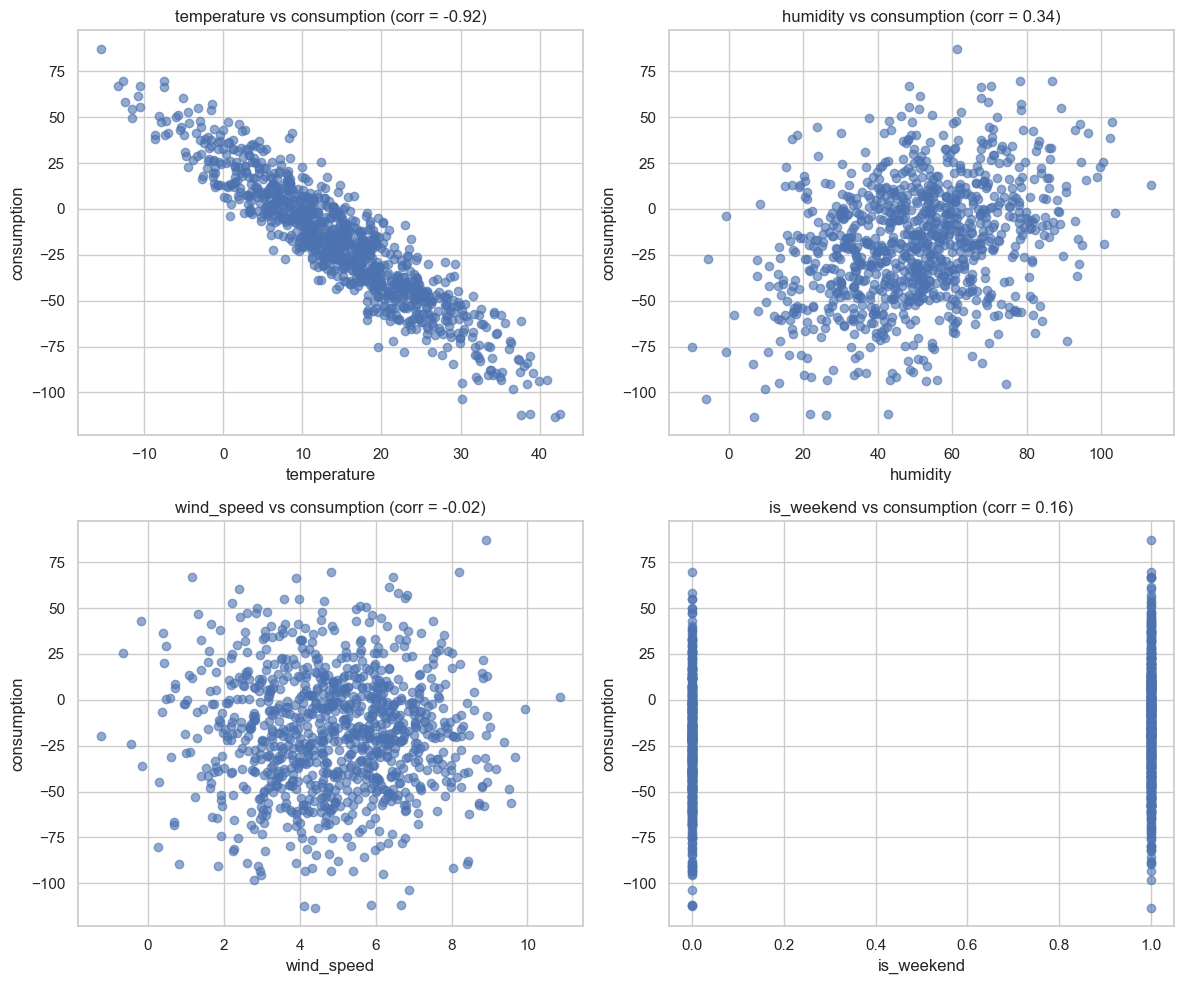

In [7]:
from scipy.stats import pearsonr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), feature_cols):
    ax.scatter(df[col], y, alpha=0.6)
    corr, _ = pearsonr(df[col], y)
    ax.set_xlabel(col)
    ax.set_ylabel('consumption')
    ax.set_title(f'{col} vs consumption (corr = {corr:.2f})')

plt.tight_layout()
plt.show()

## 8. Correlation heatmap

The heatmap summarises pairwise linear correlations among all predictors and the response. This is especially helpful for diagnosing **multicollinearity**, since strong feature-feature correlations can destabilise OLS coefficients and motivate regularisation through Ridge regression.

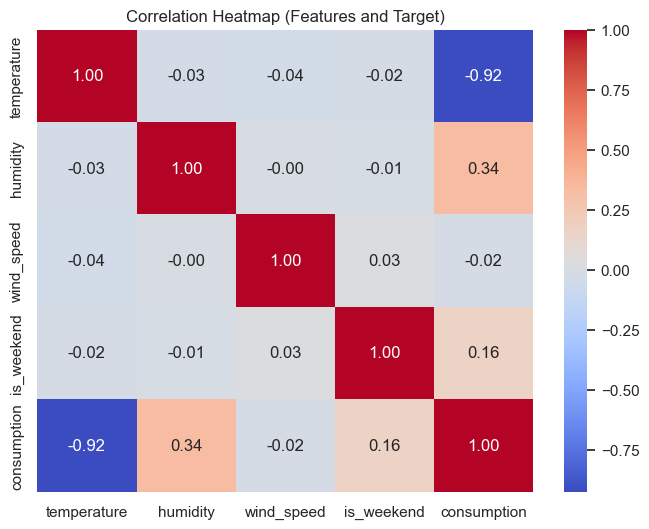

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols + ['consumption']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Features and Target)')
plt.show()

## 9. Pair plot for multivariate exploration

The pair plot offers a broader multivariate view of the dataset, combining pairwise scatter plots with marginal distributions. This can highlight clusters, skewness, and relationships that are less obvious in one-dimensional summaries.

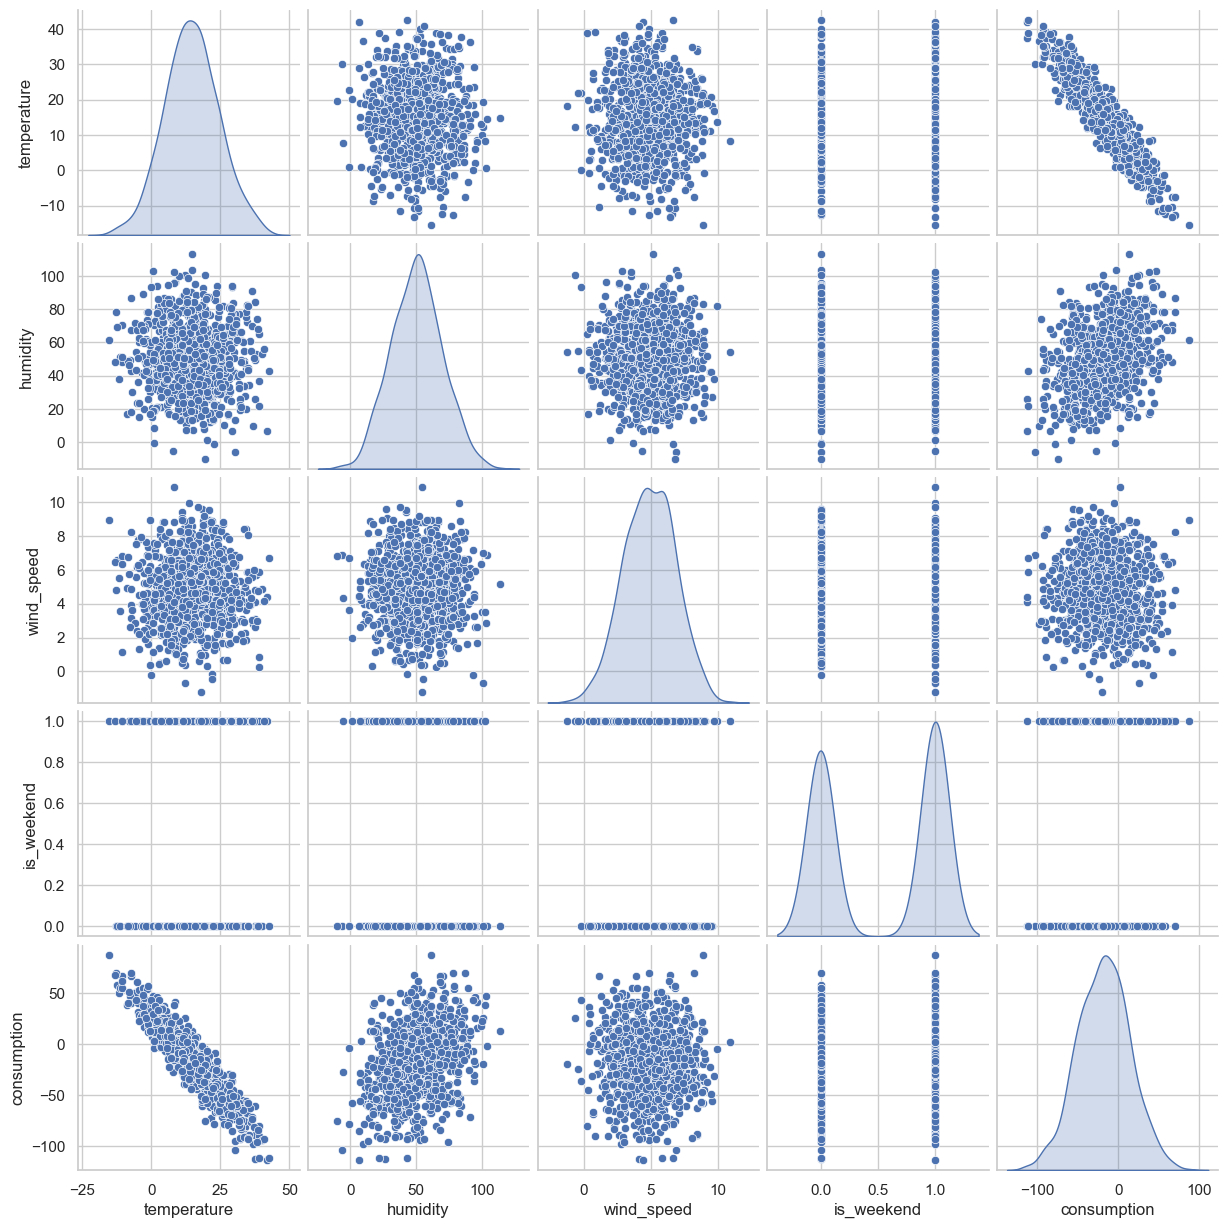

In [9]:
sns.pairplot(df[feature_cols + ['consumption']], diag_kind='kde')
plt.show()

## 10. Train-test split and feature scaling

We split the data into training and testing subsets so that model performance is assessed on unseen observations. We also standardise the features using the training data only. Standardisation is particularly important for Ridge regression because the penalty depends on the scale of the coefficients.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 11. Fit the ordinary linear regression model

We begin with the baseline **ordinary least squares** model. OLS chooses the coefficients that minimise the residual sum of squares on the training data.

### Ordinary Least Squares (OLS)

We begin with the standard linear regression model:

$$
Y = X\beta + \varepsilon,
$$

where $Y$ is the target variable, $X$ is the matrix of predictors, $\beta$ is the vector of coefficients, and $\varepsilon$ represents noise.

The Ordinary Least Squares (OLS) estimator is obtained by minimising the sum of squared residuals:

$$
\hat{\beta}^{\text{OLS}} = \arg\min_{\beta} \|Y - X\beta\|^2.
$$

The solution has a closed-form expression:

$$
\hat{\beta}^{\text{OLS}} = (X^\top X)^{-1} X^\top Y,
$$

provided that $X^\top X$ is invertible.

While OLS provides unbiased estimates under standard assumptions, it can suffer from high variance when predictors are correlated or when the model is overparameterised. This motivates the use of regularised methods such as Ridge regression.

In [11]:
linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)

y_train_pred_lin = linreg.predict(X_train_scaled)
y_test_pred_lin = linreg.predict(X_test_scaled)

## 12. Baseline OLS performance metrics

We report **mean squared error (MSE)** and **R-squared** on both the training and test sets. Looking at both is important: a very strong training fit together with noticeably weaker test performance would be a sign of overfitting.

In [28]:
metrics_lin = {
    'Model': 'Linear Regression',
    'Train MSE': mean_squared_error(y_train, y_train_pred_lin),
    'Test MSE': mean_squared_error(y_test, y_test_pred_lin),
    'Train R^2': r2_score(y_train, y_train_pred_lin),
    'Test R^2': r2_score(y_test, y_test_pred_lin)
}

pd.DataFrame([metrics_lin])

,Model,Train MSE,Test MSE,Train R^2,Test R^2
0,Linear Regression,26.37506,22.014676,0.97395,0.980814


## 13. Fit Ridge regression with cross-validation

Rather than choosing the Ridge penalty strength arbitrarily, we select it using **cross-validation** over a grid of candidate `alpha` values. This gives a more principled comparison against OLS and makes the notebook closer to realistic predictive modelling practice.

### Ridge Regression

Ridge regression extends ordinary least squares by introducing an $L^2$ penalty on the coefficients to control overfitting. The estimator is defined as:

$$
\hat{\beta}^{\text{ridge}} = \arg\min_{\beta} \left\{ \|Y - X\beta\|^2 + \alpha \|\beta\|^2 \right\}.
$$

Here, $\alpha \geq 0$ is the regularisation parameter controlling the strength of shrinkage:
- $\alpha = 0$ recovers the ordinary least squares solution,
- larger values of $\alpha$ shrink the coefficients towards zero.

This penalty helps reduce variance and improve out-of-sample performance, particularly when predictors are correlated or when the model is prone to overfitting.

In [37]:
alphas = np.logspace(-3, 3, 50)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

best_alpha = ridge_cv.alpha_
print(f'Optimal alpha from cross-validation: {best_alpha:.6f}')

ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

Optimal alpha from cross-validation: 0.039069


### Cross-Validation Error as a Function of Regularisation Strength

To better understand the selection of the regularisation parameter $\alpha$, we compute the cross-validated mean squared error for a range of candidate values. The optimal value of $\alpha$ corresponds to the minimum of this curve, illustrating the trade-off between bias and variance.

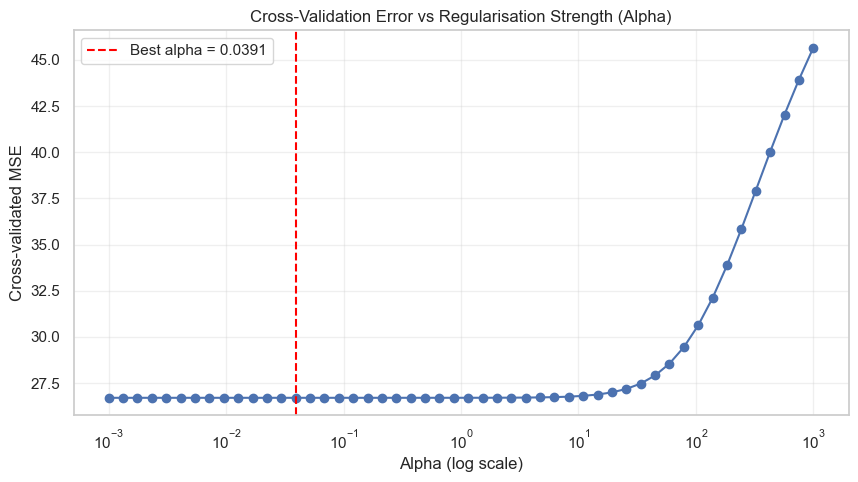

In [36]:
from sklearn.model_selection import cross_val_score

alphas = np.logspace(-3, 3, 50)

cv_errors = []

for a in alphas:
    ridge = Ridge(alpha=a)
    scores = cross_val_score(ridge, X_train, y_train,
                             scoring='neg_mean_squared_error', cv=5)
    # convert to positive MSE
    cv_errors.append(-scores.mean())

cv_errors = np.array(cv_errors)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(alphas, cv_errors, marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-Validation Error vs Regularisation Strength (Alpha)')
plt.grid(True, alpha=0.3)

# Highlight optimal alpha
best_alpha = ridge_cv.alpha_
best_error = cv_errors[np.argmin(cv_errors)]

plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best alpha = {best_alpha:.4f}')
plt.legend()

plt.show()

## 14. Ridge performance metrics

We now evaluate the cross-validated Ridge model on both the training and test sets using the same metrics as for OLS. This allows a direct comparison of predictive performance and the bias-variance tradeoff.

In [38]:
metrics_ridge = {
    'Model': 'Ridge Regression',
    'Train MSE': mean_squared_error(y_train, y_train_pred_ridge),
    'Test MSE': mean_squared_error(y_test, y_test_pred_ridge),
    'Train R^2': r2_score(y_train, y_train_pred_ridge),
    'Test R^2': r2_score(y_test, y_test_pred_ridge)
}

pd.DataFrame([metrics_ridge])

,Model,Train MSE,Test MSE,Train R^2,Test R^2
0,Ridge Regression,26.375062,22.01709,0.97395,0.980812


## 15. Compare train and test performance across models

A side-by-side table makes it easier to judge whether Ridge improves out-of-sample performance, even if only slightly. In synthetic data generated from a stable linear relationship, it is common for OLS and Ridge to perform similarly, but Ridge may still provide more stable coefficient estimates.

In [39]:
performance_df = pd.DataFrame([metrics_lin, metrics_ridge])
performance_df

,Model,Train MSE,Test MSE,Train R^2,Test R^2
0,Linear Regression,26.375060,22.014676,0.97395,0.980814
1,Ridge Regression,26.375062,22.017090,0.97395,0.980812


## 16. Compare estimated coefficients with the true data-generating coefficients

Because the dataset is synthetic, we know the underlying coefficient vector `true_beta`. This lets us compare the fitted coefficients with the true signal.

A subtle but important point is that both OLS and Ridge were fitted on **standardised predictors**. Therefore, the raw coefficients returned by `linreg.coef_` and `ridge.coef_` are on the **scaled-feature scale**, not on the original scale used to generate the data. That is why, for example, the temperature coefficient may appear much larger in magnitude than its true coefficient.

If a predictor is standardised as

$$
Z_j = \frac{X_j - \mu_j}{\sigma_j},
$$

then the coefficient on the scaled variable satisfies

$$
\gamma_j = \beta_j \sigma_j.
$$

So to compare estimated coefficients with `true_beta`, we convert them back to the **original feature scale** by dividing by `scaler.scale_`.


In [40]:
# Coefficients returned by the fitted models are on the scaled-feature scale.
# Convert them back to the original feature scale for a fair comparison
# with the true data-generating coefficients.

ols_coef_scaled = linreg.coef_
ridge_coef_scaled = ridge.coef_

ols_coef_original = ols_coef_scaled / scaler.scale_
ridge_coef_original = ridge_coef_scaled / scaler.scale_

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'True coefficient': true_beta,
    'OLS coefficient (original scale)': ols_coef_original,
    'Ridge coefficient (original scale)': ridge_coef_original,
    'OLS coefficient (scaled features)': ols_coef_scaled,
    'Ridge coefficient (scaled features)': ridge_coef_scaled,
    'Feature std. dev.': scaler.scale_
})

coef_df

,Feature,True coefficient,OLS coefficient (original scale),Ridge coefficient (original scale),OLS coefficient (scaled features),Ridge coefficient (scaled features),Feature std. dev.
0,temperature,-3.0,-2.974285,-2.974140,-29.328946,-29.327515,9.860840
1,humidity,0.5,0.508701,0.508677,9.662365,9.661911,18.994188
2,wind_speed,-1.0,-0.983300,-0.983215,-1.832243,-1.832083,1.863360
3,is_weekend,10.0,9.894416,9.893938,4.941020,4.940781,0.499375


The table should now be interpreted column by column:

- **True coefficient**: the coefficient used to generate the synthetic target.
- **OLS/Ridge coefficient (original scale)**: directly comparable with the true coefficient.
- **OLS/Ridge coefficient (scaled features)**: coefficients from the model fit on standardised predictors.
- **Feature std. dev.**: explains why scaled coefficients can look much larger or smaller numerically.

For instance, if temperature has standard deviation around 10, then a true coefficient of about `-3` corresponds to a scaled-feature coefficient of about `-30`, which is exactly what we would expect after standardisation.


## 17. Interpret the weekend effect separately

The weekend indicator is a useful example of a binary predictor. Looking at its estimated coefficient helps interpret whether energy consumption tends to be higher or lower on weekends, holding the other variables fixed.

In [41]:
weekend_row = coef_df[coef_df['Feature'] == 'is_weekend']
weekend_row

,Feature,True coefficient,OLS coefficient (original scale),Ridge coefficient (original scale),OLS coefficient (scaled features),Ridge coefficient (scaled features),Feature std. dev.
3,is_weekend,10.0,9.894416,9.893938,4.94102,4.940781,0.499375


## 18. Visual comparison of coefficient estimates

This bar chart compares the true coefficients with the OLS and Ridge estimates. Ridge is expected to shrink coefficients towards zero relative to OLS, reflecting the regularisation penalty.

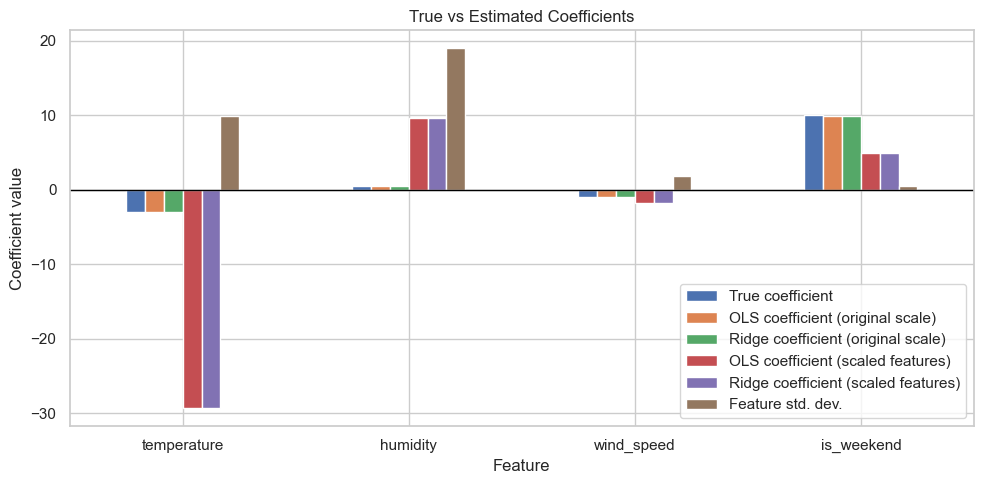

In [42]:
coef_plot_df = coef_df.set_index('Feature')
coef_plot_df.plot(kind='bar', figsize=(10, 5))
plt.axhline(0, color='black', linewidth=1)
plt.title('True vs Estimated Coefficients')
plt.ylabel('Coefficient value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 19. Ridge coefficient paths as the penalty varies

A classic Ridge diagnostic is the **coefficient path plot**. As the regularisation strength `alpha` increases, the coefficients are increasingly shrunk towards zero. This illustrates how Ridge trades variance reduction for additional bias.

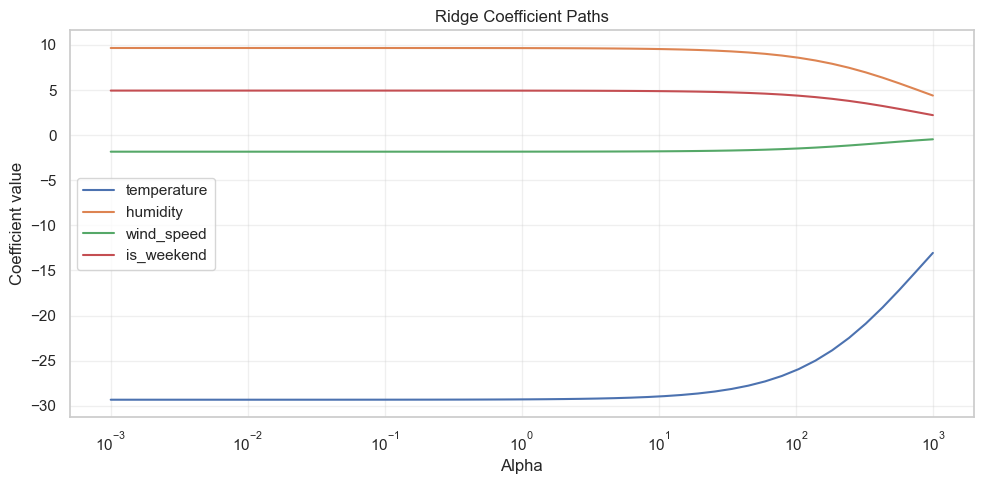

In [43]:
coefs = []
for a in alphas:
    ridge_temp = Ridge(alpha=a)
    ridge_temp.fit(X_train_scaled, y_train)
    coefs.append(ridge_temp.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(10, 5))
for i, feature in enumerate(feature_cols):
    plt.plot(alphas, coefs[:, i], label=feature)

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Paths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Actual vs predicted values for both models

Plotting predictions against actual values gives an intuitive sense of predictive quality. Points close to the 45-degree line indicate accurate predictions. This also makes it easy to see whether Ridge materially changes the fit relative to OLS.

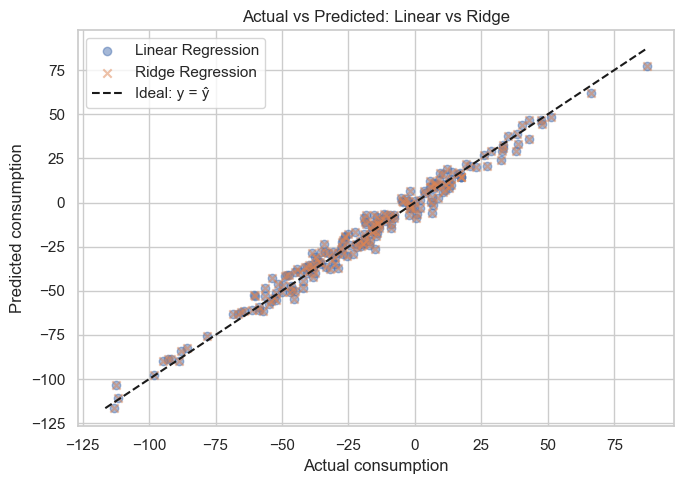

In [44]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_test_pred_lin, alpha=0.5, label='Linear Regression')
ax.scatter(y_test, y_test_pred_ridge, alpha=0.5, label='Ridge Regression', marker='x')

min_val = min(y_test.min(), y_test_pred_lin.min(), y_test_pred_ridge.min())
max_val = max(y_test.max(), y_test_pred_lin.max(), y_test_pred_ridge.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal: y = ŷ')

ax.set_xlabel('Actual consumption')
ax.set_ylabel('Predicted consumption')
ax.set_title('Actual vs Predicted: Linear vs Ridge')
ax.legend()
plt.tight_layout()
plt.show()

## 21. Residual diagnostics for OLS

Residual diagnostics help us judge whether the linear model assumptions are reasonable. We examine:
- residuals versus fitted values, to check for patterns or heteroscedasticity,
- a histogram, to assess shape and symmetry,
- a Q-Q plot, to compare the residual distribution with a normal distribution.

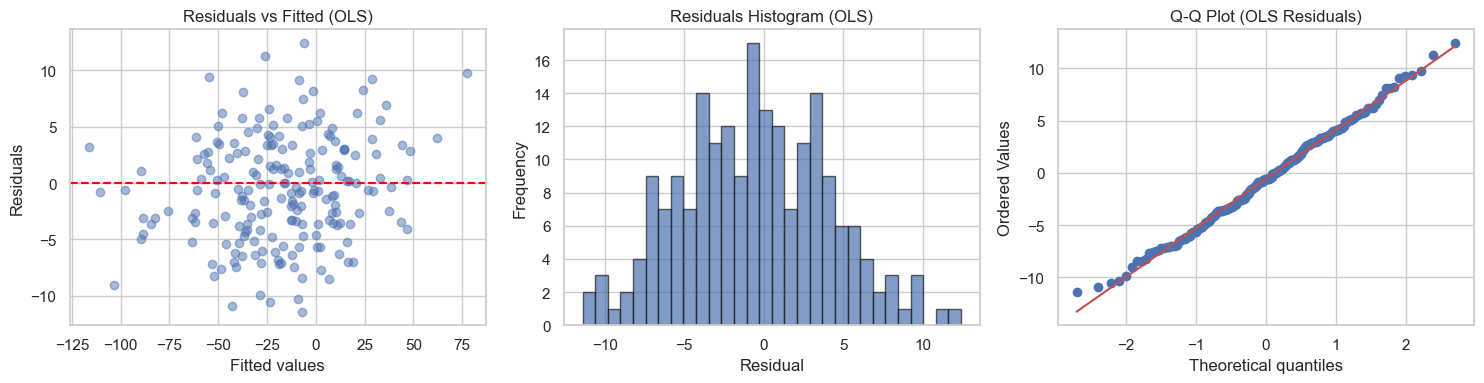

In [45]:
residuals_lin = y_test - y_test_pred_lin

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test_pred_lin, residuals_lin, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (OLS)')

axes[1].hist(residuals_lin, bins=30, edgecolor='k', alpha=0.7)
axes[1].set_title('Residuals Histogram (OLS)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

stats.probplot(residuals_lin, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (OLS Residuals)')

plt.tight_layout()
plt.show()

## 22. Residual diagnostics for Ridge

We repeat the same diagnostic checks for Ridge regression. This is useful because even if both models have similar predictive metrics, their residual behaviour may differ slightly, especially in terms of spread and outlier sensitivity.

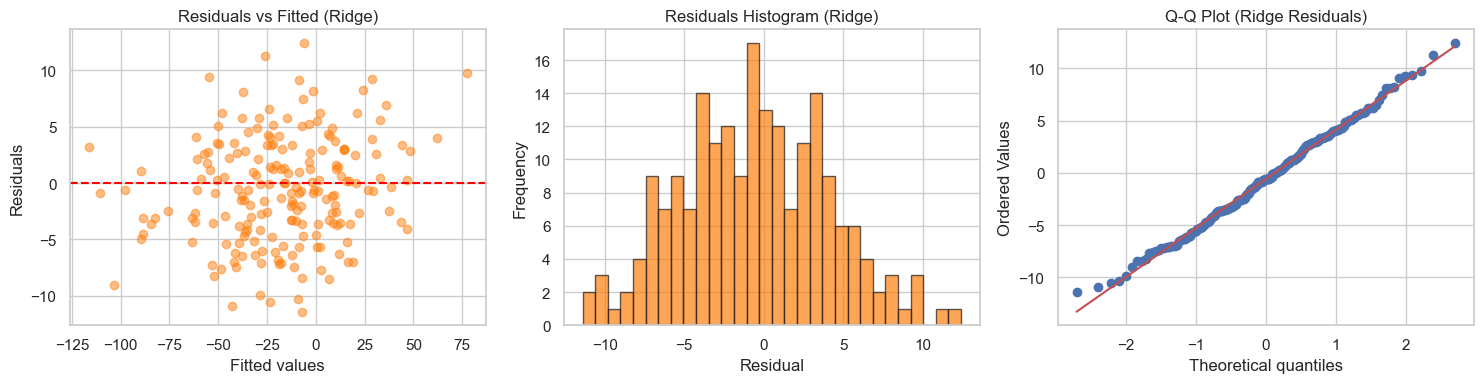

In [46]:
residuals_ridge = y_test - y_test_pred_ridge

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_test_pred_ridge, residuals_ridge, alpha=0.5, color='tab:orange')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted (Ridge)')

axes[1].hist(residuals_ridge, bins=30, edgecolor='k', alpha=0.7, color='tab:orange')
axes[1].set_title('Residuals Histogram (Ridge)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

stats.probplot(residuals_ridge, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (Ridge Residuals)')

plt.tight_layout()
plt.show()

## 23. Direct comparison of residual distributions across models

The combined plots below compare OLS and Ridge residuals directly. The histogram and boxplot are useful for assessing whether Ridge produces a tighter error distribution or reduces the impact of large residuals.

C:\Users\u1302140\AppData\Local\Temp\ipykernel_12152\3064853814.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([residuals_lin, residuals_ridge], labels=['Linear', 'Ridge'], showmeans=True)


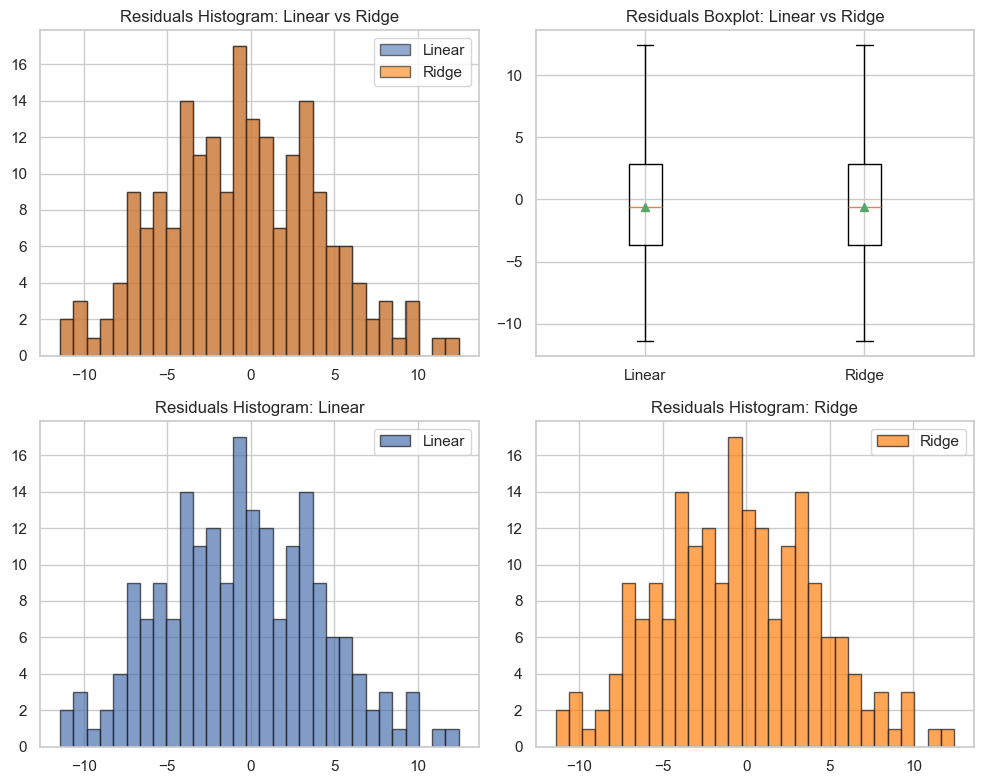

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

axes[0].hist(residuals_lin, bins=30, alpha=0.6, label='Linear', edgecolor='k')
axes[0].hist(residuals_ridge, bins=30, alpha=0.6, label='Ridge', edgecolor='k', color='tab:orange')
axes[0].set_title('Residuals Histogram: Linear vs Ridge')
axes[0].legend()

axes[1].boxplot([residuals_lin, residuals_ridge], labels=['Linear', 'Ridge'], showmeans=True)
axes[1].set_title('Residuals Boxplot: Linear vs Ridge')

axes[2].hist(residuals_lin, bins=30, alpha=0.7, label='Linear', edgecolor='k')
axes[2].set_title('Residuals Histogram: Linear')
axes[2].legend()

axes[3].hist(residuals_ridge, bins=30, alpha=0.7, label='Ridge', edgecolor='k', color='tab:orange')
axes[3].set_title('Residuals Histogram: Ridge')
axes[3].legend()

plt.tight_layout()
plt.show()

## 24. Noise sensitivity experiment

Because this is a simulated dataset, we can investigate how the two models behave as the noise level increases. This gives a useful illustration of when regularisation is likely to matter more. When noise becomes larger, coefficient estimates tend to become more variable, and Ridge may gain an advantage through shrinkage.

In [48]:
noise_levels = [1, 5, 10, 20]
results = []

for sigma in noise_levels:
    noise_sigma = sigma * np.random.randn(n)
    y_sigma = X.values @ true_beta + noise_sigma

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X, y_sigma, test_size=0.2, random_state=42
    )

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled = scaler_s.transform(X_test_s)

    lin_s = LinearRegression().fit(X_train_s_scaled, y_train_s)
    ridge_cv_s = RidgeCV(alphas=alphas, cv=5).fit(X_train_s_scaled, y_train_s)
    ridge_s = Ridge(alpha=ridge_cv_s.alpha_).fit(X_train_s_scaled, y_train_s)

    y_pred_lin_s = lin_s.predict(X_test_s_scaled)
    y_pred_ridge_s = ridge_s.predict(X_test_s_scaled)

    results.append({
        'Noise std': sigma,
        'OLS Test MSE': mean_squared_error(y_test_s, y_pred_lin_s),
        'Ridge Test MSE': mean_squared_error(y_test_s, y_pred_ridge_s),
        'Chosen Ridge alpha': ridge_cv_s.alpha_
    })

noise_results_df = pd.DataFrame(results)
noise_results_df

,Noise std,OLS Test MSE,Ridge Test MSE,Chosen Ridge alpha
0,1,0.995561,0.995564,0.001000
1,5,24.775405,24.781689,0.159986
2,10,95.753603,95.776212,2.023590
3,20,381.626064,381.776027,6.250552


## 25. Visualise how test error changes with noise

The chart below shows how out-of-sample error evolves as the noise level increases. This is a direct illustration of the bias-variance tradeoff: when noise is low, OLS may perform similarly to Ridge; when noise rises, regularisation can become more beneficial.

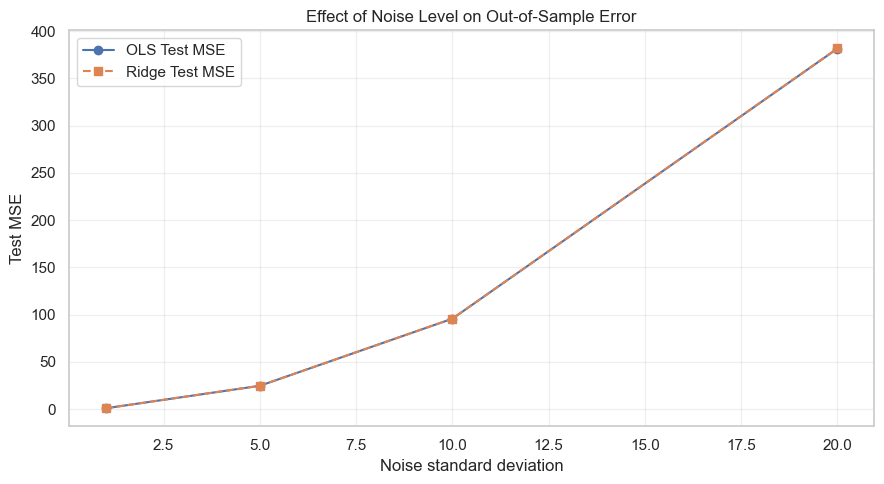

In [56]:
plt.figure(figsize=(9, 5))
plt.plot(noise_results_df['Noise std'], noise_results_df['OLS Test MSE'], marker='o', label='OLS Test MSE')
plt.plot(noise_results_df['Noise std'], noise_results_df['Ridge Test MSE'], marker='s',linestyle='--', label='Ridge Test MSE')
plt.xlabel('Noise standard deviation')
plt.ylabel('Test MSE')
plt.title('Effect of Noise Level on Out-of-Sample Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 26. Final conclusions

This notebook illustrates several important ideas from regression modelling:

- The synthetic data were generated from a linear structure, so both OLS and Ridge are well suited to the problem.
- OLS provides a natural baseline and, in a stable low-noise linear setting, can perform very well on both training and test data.
- Ridge regression introduces coefficient shrinkage, which helps stabilise estimates when predictors are correlated or when the data become noisier.
- Cross-validating the Ridge penalty makes the comparison more principled than fixing the regularisation strength by hand.
- Comparing estimated coefficients with the true data-generating coefficients is especially valuable here because it separates **predictive accuracy** from **parameter recovery**.
- Residual histograms, residual-vs-fitted plots, and Q-Q plots suggest whether the linear modelling assumptions are broadly reasonable and whether error behaviour differs across models.
- The noise sensitivity experiment shows the key modelling lesson: **regularisation is most useful when variance becomes a bigger problem**, even if OLS is already adequate in cleaner settings. While OLS performs well in low-noise settings, higher noise leads to unstable coefficient estimates, making stronger regularisation (larger $\alpha$) beneficial for improving out-of-sample performance.

Overall, this notebook demonstrates not only how to fit OLS and Ridge models, but also how to evaluate them through performance metrics, coefficient analysis, residual diagnostics, and robustness checks. That gives a much more complete picture of model behaviour than reporting test error alone.